# Chapter 8: Continuing Expressions

In [1]:
import polars as pl
pl.__version__  # The book is built with Polars version 1.20.0

'1.33.0'

In [2]:
import math
import numpy as np

print(f"{math.pi=}")
rng = np.random.default_rng(1729)
print(f"{rng.random()=}")

math.pi=3.141592653589793
rng.random()=0.03074202960516803


## 8.1 Types of Operations

Operations that:<br>
1. Keep length: Element-wise, Series-wise<br>
2. Compress length: Single value, Single/Multiple values<br>
3. Extend length

### 8.1.1 Example A: Element-Wise Operations

Keep length, Element-wise

In [3]:
penguins = pl.read_csv("data/penguins.csv", null_values="NA").select(
    "species",
    "island",
    "sex",
    "year",
    mass=pl.col("body_mass_g") / 1000,
)
penguins.with_columns(
    mass_sqrt=pl.col("mass").sqrt(),  
    mass_exp=pl.col("mass").exp(),
)

species,island,sex,year,mass,mass_sqrt,mass_exp
str,str,str,i64,f64,f64,f64
"""Adelie""","""Torgersen""","""male""",2007,3.75,1.936492,42.521082
"""Adelie""","""Torgersen""","""female""",2007,3.8,1.949359,44.701184
"""Adelie""","""Torgersen""","""female""",2007,3.25,1.802776,25.79034
"""Adelie""","""Torgersen""",null,2007,null,null,null
"""Adelie""","""Torgersen""","""female""",2007,3.45,1.857418,31.500392
…,…,…,…,…,…,…
"""Chinstrap""","""Dream""","""male""",2009,4.0,2.0,54.59815
"""Chinstrap""","""Dream""","""female""",2009,3.4,1.843909,29.9641
"""Chinstrap""","""Dream""","""male""",2009,3.775,1.942936,43.597508


### 8.1.2 Example B: Operations That Summarize to One

Compress length, Single value

In [4]:
penguins.select(pl.col("mass").mean(), pl.col("island").first())

mass,island
f64,str
4.201754,"""Torgersen"""


### 8.1.3 Example C: Operations That Summarize to One or More

Compress length, Single/Multiple values

In [5]:
penguins.select(pl.col("island").unique())

island
str
"""Torgersen"""
"""Dream"""
"""Biscoe"""


### 8.1.4 Example D: Operations That Extend

Extend length

In [6]:
penguins.select(
    pl.col("species")
    .unique()  # get 3 unique values
    .repeat_by(3000)  # get a series of 3 long lists
    .explode()  # flatten to 1 list (series)
    .extend_constant("Saiyan", n=1)  # append another value
)

species
str
"""Chinstrap"""
"""Chinstrap"""
"""Chinstrap"""
"""Chinstrap"""
"""Chinstrap"""
…
"""Adelie"""
"""Adelie"""
"""Adelie"""


## 8.2 Element-Wise Operations

Order of elements won't affect op results<br>
NaN result won't affect other results

### 8.2.1 Operations That Perform Mathematical Transformations

cbrt() cube root, log1p() is log(1+x)<br>

In [7]:
(
    pl.DataFrame({"x": [-2.0, 0.0, 0.5, 1.0, math.e, 1000.0]}).with_columns(
        abs=pl.col("x").abs(),
        exp=pl.col("x").exp(),
        log2=pl.col("x").log(2),  
        log10=pl.col("x").log10(),
        log1p=pl.col("x").log1p(),
        sign=pl.col("x").sign(),
        sqrt=pl.col("x").sqrt(),
    )
)

x,abs,exp,log2,log10,log1p,sign,sqrt
f64,f64,f64,f64,f64,f64,f64,f64
-2.0,2.0,0.135335,NaN,NaN,NaN,-1.0,NaN
0.0,0.0,1.0,-inf,-inf,0.0,0.0,0.0
0.5,0.5,1.648721,-1.0,-0.30103,0.405465,1.0,0.707107
1.0,1.0,2.718282,0.0,0.0,0.693147,1.0,1.0
2.718282,2.718282,15.154262,1.442695,0.434294,1.313262,1.0,1.648721
1000.0,1000.0,inf,9.965784,3.0,6.908755,1.0,31.622777


### 8.2.2 Operations Related to Trigonometry

In [8]:
(
    pl.DataFrame(
        {"x": [-math.pi, 0.0, 1.0, math.pi, 2 * math.pi, 90.0, 180.0, 360.0]}
    ).with_columns(
        arccos=pl.col("x").arccos(),  
        cos=pl.col("x").cos(),
        degrees=pl.col("x").degrees(),
        radians=pl.col("x").radians(),
        sin=pl.col("x").sin(),
    )
)

x,arccos,cos,degrees,radians,sin
f64,f64,f64,f64,f64,f64
-3.141593,NaN,-1.0,-180.0,-0.054831,-1.2246e-16
0.0,1.570796,1.0,0.0,0.0,0.0
1.0,0.0,0.540302,57.29578,0.017453,0.841471
3.141593,NaN,-1.0,180.0,0.054831,1.2246e-16
6.283185,NaN,1.0,360.0,0.109662,-2.4493e-16
90.0,NaN,-0.448074,5156.620156,1.570796,0.893997
180.0,NaN,-0.59846,10313.240312,3.141593,-0.801153
360.0,NaN,-0.283691,20626.480625,6.283185,0.958916


### 8.2.3 Operations That Round and Categorize

In [9]:
(
    pl.DataFrame(
        {"x": [-6.0, -0.5, 0.0, 0.5, math.pi, 9.9, 9.99, 9.999]}
    ).with_columns(
        ceil=pl.col("x").ceil(),
        clip=pl.col("x").clip(-1, 1),
        cut=pl.col("x").cut([-1, 1], labels=["bad", "neutral", "good"]),  
        floor=pl.col("x").floor(),
        qcut=pl.col("x").qcut([0.5], labels=["below median", "above median"]),
        round2=pl.col("x").round(2),
        round0=pl.col("x").round(0),  
    )
)

x,ceil,clip,cut,floor,qcut,round2,round0
f64,f64,f64,cat,f64,cat,f64,f64
-6.0,-6.0,-1.0,"""bad""",-6.0,"""below median""",-6.0,-6.0
-0.5,-0.0,-0.5,"""neutral""",-1.0,"""below median""",-0.5,-0.0
0.0,0.0,0.0,"""neutral""",0.0,"""below median""",0.0,0.0
0.5,1.0,0.5,"""neutral""",0.0,"""below median""",0.5,0.0
3.141593,4.0,1.0,"""good""",3.0,"""above median""",3.14,3.0
9.9,10.0,1.0,"""good""",9.0,"""above median""",9.9,10.0
9.99,10.0,1.0,"""good""",9.0,"""above median""",9.99,10.0
9.999,10.0,1.0,"""good""",9.0,"""above median""",10.0,10.0


### 8.2.4 Operations for Missing or Infinite Values

NaN != null (None)

In [10]:
x = [42.0, math.nan, None, math.inf, -math.inf]
(
    pl.DataFrame({"x": x}).with_columns(
        fill_nan=pl.col("x").fill_nan(999),
        fill_null=pl.col("x").fill_null(0),  
        is_finite=pl.col("x").is_finite(),
        is_infinite=pl.col("x").is_infinite(),
        is_nan=pl.col("x").is_nan(),
        is_null=pl.col("x").is_null(),
    )
)

x,fill_nan,fill_null,is_finite,is_infinite,is_nan,is_null
f64,f64,f64,bool,bool,bool,bool
42.0,42.0,42.0,true,false,false,false
NaN,999.0,NaN,false,false,true,false
null,null,0.0,null,null,null,true
inf,inf,inf,false,true,false,false
-inf,-inf,-inf,false,true,false,false


In [11]:
(
    pl.DataFrame({"x": x}).with_columns(
        fill_both=pl.col("x").fill_nan(0).fill_null(0),
        is_either=(pl.col("x").is_nan() | pl.col("x").is_null()),
    )
)

x,fill_both,is_either
f64,f64,bool
42.0,42.0,false
NaN,0.0,true
null,0.0,true
inf,inf,false
-inf,-inf,false


### 8.2.5 Other Operations

In [12]:
(
    pl.DataFrame({"x": ["here", "there", "their", "they're"]}).with_columns(
        hash=pl.col("x").hash(seed=1337),  
        repeat_by=pl.col("x").repeat_by(3),
        replace=pl.col("x").replace(
            {
                "here": "there",
                "they're": "they are",
            }
        ),
    )
)

x,hash,repeat_by,replace
str,u64,list[str],str
"""here""",2032125378654673168,"[""here"", ""here"", ""here""]","""there"""
"""there""",3904125460615262699,"[""there"", ""there"", ""there""]","""there"""
"""their""",14795748473133952028,"[""their"", ""their"", ""their""]","""their"""
"""they're""",5079056524477645000,"[""they're"", ""they're"", ""they're""]","""they are"""


## 8.3 Nonreducing Series-Wise Operations

Keep length, Series-wise

### 8.3.1 Operations That Accumulate

`cum_count()` exclude null(None)<br>

NaN can be contageous<br>
`cum_prod()` and `cum_sum()` are continuously affected<br>
`cum_count()`, `cum_max/min()` not affected<br>
`diff()` and `pct_change()` only neighboring results affected

In [13]:
(
    pl.DataFrame(
        {"x": [0.0, 1.0, 2.0, None, 2.0, np.nan, -1.0, 2.0]}
    ).with_columns(
        cum_count=pl.col("x").cum_count(),  
        cum_max=pl.col("x").cum_max(),
        cum_min=pl.col("x").cum_min(),
        cum_prod=pl.col("x").cum_prod(reverse=True),  
        cum_sum=pl.col("x").cum_sum(),
        diff=pl.col("x").diff(),
        pct_change=pl.col("x").pct_change(),
    )
)

x,cum_count,cum_max,cum_min,cum_prod,cum_sum,diff,pct_change
f64,u32,f64,f64,f64,f64,f64,f64
0.0,1,0.0,0.0,NaN,0.0,null,null
1.0,2,1.0,0.0,NaN,1.0,1.0,inf
2.0,3,2.0,0.0,NaN,3.0,1.0,1.0
null,3,null,null,null,null,null,0.0
2.0,4,2.0,0.0,NaN,5.0,null,0.0
NaN,5,2.0,0.0,NaN,NaN,NaN,NaN
-1.0,6,2.0,-1.0,-2.0,NaN,NaN,NaN
2.0,7,2.0,-1.0,2.0,NaN,3.0,-3.0


### 8.3.2 Operations That Fill and Shift

NaN won't be filled or interpolated

In [14]:
(
    pl.DataFrame(
        {"x": [-1.0, 0.0, 1.0, None, None, 3.0, 4.0, math.nan, 6.0]}
    ).with_columns(
        backward_fill=pl.col("x").backward_fill(),  
        forward_fill=pl.col("x").forward_fill(limit=1),
        interp1=pl.col("x").interpolate(method="linear"),  
        interp2=pl.col("x").interpolate(method="nearest"),
        shift1=pl.col("x").shift(1),
        shift2=pl.col("x").shift(-2),
    )
)

x,backward_fill,forward_fill,interp1,interp2,shift1,shift2
f64,f64,f64,f64,f64,f64,f64
-1.0,-1.0,-1.0,-1.0,-1.0,null,1.0
0.0,0.0,0.0,0.0,0.0,-1.0,null
1.0,1.0,1.0,1.0,1.0,0.0,null
null,3.0,1.0,1.666667,1.0,1.0,3.0
null,3.0,null,2.333333,3.0,null,4.0
3.0,3.0,3.0,3.0,3.0,null,NaN
4.0,4.0,4.0,4.0,4.0,3.0,6.0
NaN,NaN,NaN,NaN,NaN,4.0,null
6.0,6.0,6.0,6.0,6.0,NaN,null


### 8.3.3 Operations Related to Duplicate Values

In [15]:
(
    pl.DataFrame({"x": ["A", "C", "D", "C"]}).with_columns(  
        is_duplicated=pl.col("x").is_duplicated(),
        is_first_distinct=pl.col("x").is_first_distinct(),
        is_last_distinct=pl.col("x").is_last_distinct(),
        is_unique=pl.col("x").is_unique(),
    )
)

x,is_duplicated,is_first_distinct,is_last_distinct,is_unique
str,bool,bool,bool,bool
"""A""",false,true,true,true
"""C""",true,true,false,false
"""D""",false,true,true,true
"""C""",true,false,true,false


### 8.3.4 Operations That Compute Rolling Statistics

In [16]:
stock = (
    pl.read_csv("data/stock/nvda/2023.csv", try_parse_dates=True)
    .select("date", "close")
    .with_columns(
        ewm_mean=pl.col("close").ewm_mean(com=7, ignore_nulls=True),  
        rolling_mean=pl.col("close").rolling_mean(window_size=7),
        rolling_min=pl.col("close").rolling_min(window_size=7),
    )
)

stock

date,close,ewm_mean,rolling_mean,rolling_min
date,f64,f64,f64,f64
2023-01-03,143.149994,143.149994,null,null
2023-01-04,147.490005,145.464667,null,null
2023-01-05,142.649994,144.398755,null,null
2023-01-06,148.589996,145.664782,null,null
2023-01-09,156.279999,148.388917,null,null
…,…,…,…,…
2023-06-26,406.320007,407.54911,425.805716,406.320007
2023-06-27,418.76001,408.950473,424.695718,406.320007
2023-06-28,411.170013,409.227915,422.445718,406.320007


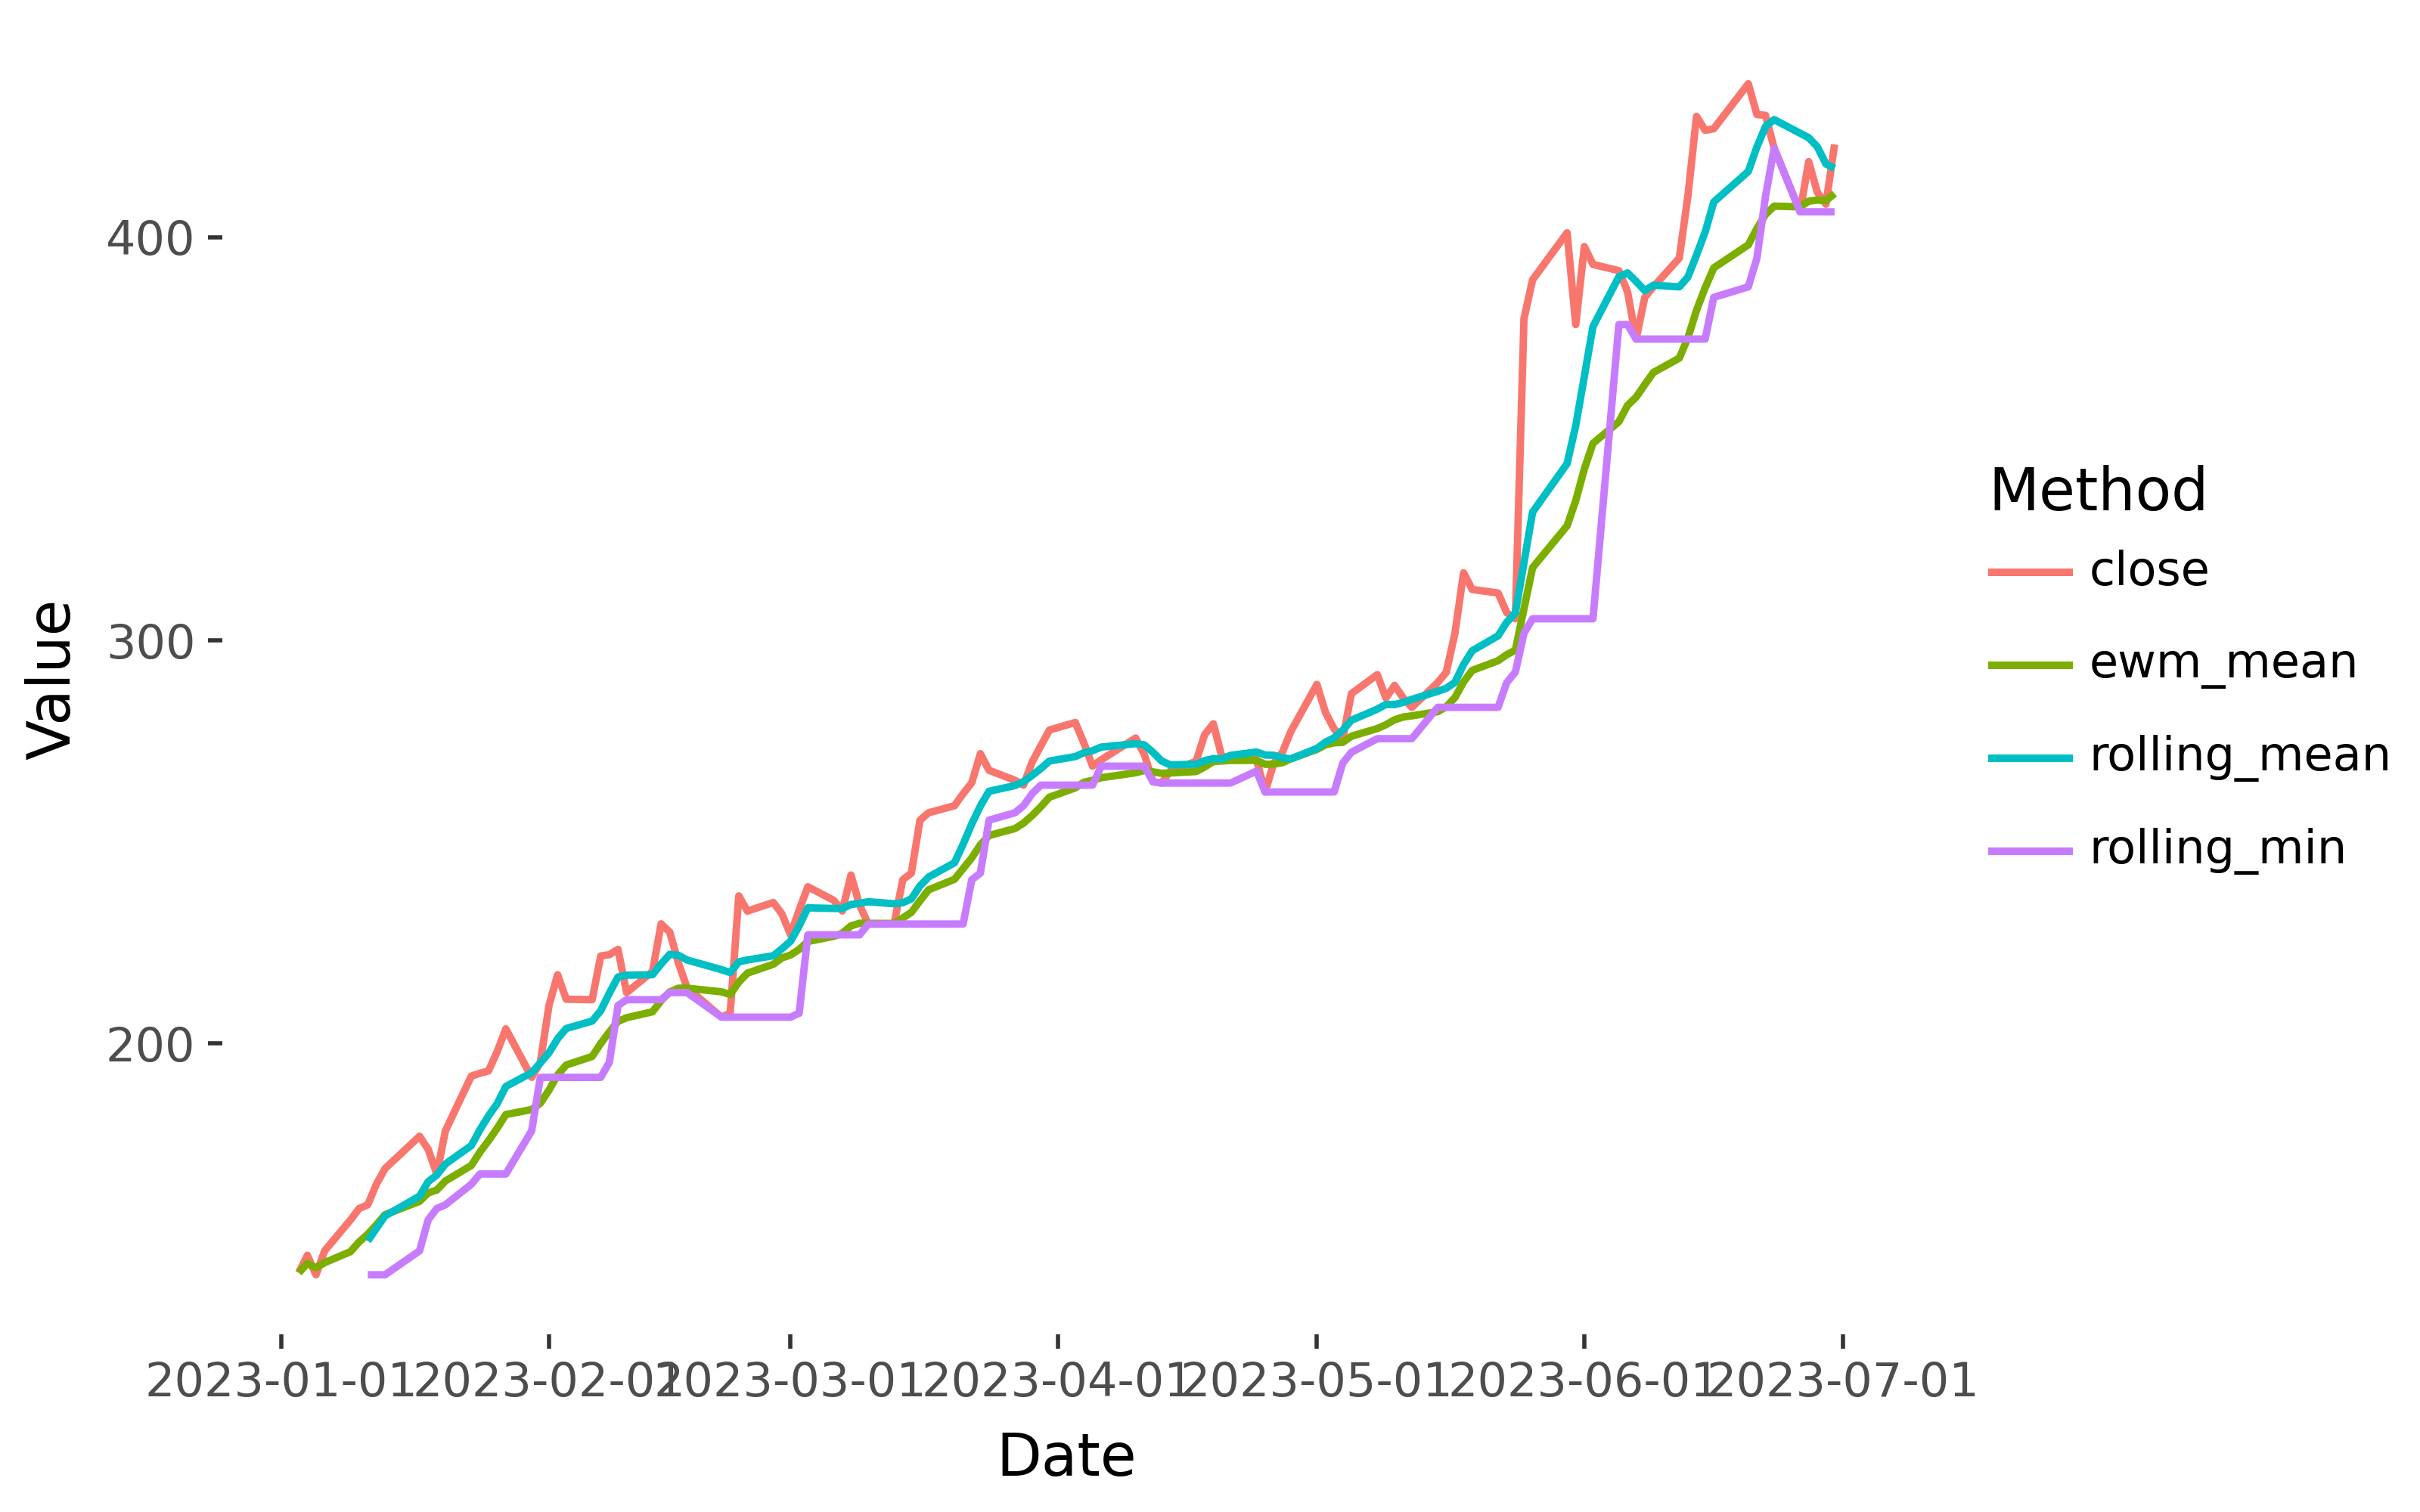

In [17]:
from plotnine import *

(
    ggplot(stock.unpivot(index="date"), aes("date", "value", color="variable"))
    + geom_line(size=1)
    + labs(x="Date", y="Value", color="Method")
    + theme_tufte(base_size=14)
    + theme(figure_size=(8, 5), dpi=200)
)

### 8.3.5 Operations That Sort

In [18]:
(
    pl.DataFrame(
        {
            "x": [1, 3, None, 3, 7],
            "y": ["D", "I", "S", "C", "O"],
        }
    ).with_columns(
        arg_sort=pl.col("x").arg_sort(),
        shuffle=pl.col("x").shuffle(seed=7),
        sort=pl.col("x").sort(nulls_last=True),
        sort_by=pl.col("x").sort_by("y"),
        reverse=pl.col("x").reverse(),
        rank=pl.col("x").rank(),
    )
)

x,y,arg_sort,shuffle,sort,sort_by,reverse,rank
i64,str,u32,i64,i64,i64,i64,f64
1,"""D""",2,7,1,3,7,1.0
3,"""I""",0,3,3,1,3,2.5
null,"""S""",1,3,3,3,null,null
3,"""C""",3,null,7,7,3,2.5
7,"""O""",4,1,null,null,1,4.0


### 8.3.6 Other Operations

`expr.rle_id()` idx increase for each value change

In [19]:
(
    pl.DataFrame({"x": [33, 33, 27, 33, 60, 60, 60, 33, 60]}).with_columns(
        rle_id=pl.col("x").rle_id(),
    )
)

x,rle_id
i64,u32
33,0
33,0
27,1
33,2
60,3
60,3
60,3
33,4
60,5


## 8.4 Series-Wise Operations That Summarize to One

Compress length, Single value

In [20]:
(
    pl.DataFrame({"x": [1, 3, 3, 7]}).with_columns(
        mean=pl.col("x").mean(),
    )
)

x,mean
i64,f64
1,3.5
3,3.5
3,3.5
7,3.5


In [21]:
(
    pl.DataFrame({"cluster": ["a", "a", "b", "b"], "x": [1, 3, 3, 7]})
    .group_by("cluster")
    .agg(
        mean=pl.col("x").mean(),
    )
)

cluster,mean
str,f64
"""a""",2.0
"""b""",5.0


### 8.4.1 Operations That Are Quantifiers

`expr.all()`, `expr.any()`

In [22]:
df = pl.DataFrame(
    {
        "x": [True, False, False],
        "y": [True, True, True],
        "z": [False, False, False],
    }
)
print(df)
print(
    df.select(
        pl.all().all().name.suffix("_all"),
        pl.all().any().name.suffix("_any"),
    ),
)

shape: (3, 3)
┌───────┬──────┬───────┐
│ x     ┆ y    ┆ z     │
│ ---   ┆ ---  ┆ ---   │
│ bool  ┆ bool ┆ bool  │
╞═══════╪══════╪═══════╡
│ true  ┆ true ┆ false │
│ false ┆ true ┆ false │
│ false ┆ true ┆ false │
└───────┴──────┴───────┘
shape: (1, 6)
┌───────┬───────┬───────┬───────┬───────┬───────┐
│ x_all ┆ y_all ┆ z_all ┆ x_any ┆ y_any ┆ z_any │
│ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ bool  ┆ bool  ┆ bool  ┆ bool  ┆ bool  ┆ bool  │
╞═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ false ┆ true  ┆ false ┆ true  ┆ true  ┆ false │
└───────┴───────┴───────┴───────┴───────┴───────┘


### 8.4.2 Operations That Compute Statistics

In [23]:
samples = rng.normal(loc=5, scale=3, size=1_000_000)

(
    pl.DataFrame({"x": samples}).select(
        max=pl.col("x").max(),
        mean=pl.col("x").mean(),
        quantile=pl.col("x").quantile(quantile=0.95),
        skew=pl.col("x").skew(),
        std=pl.col("x").std(),
        sum=pl.col("x").sum(),
        var=pl.col("x").var(),
    )
)

max,mean,quantile,skew,std,sum,var
f64,f64,f64,f64,f64,f64,f64
20.752443,4.994978,9.931565,0.003245,2.999926,4.9950e6,8.999558


### 8.4.3 Operations That Count

In [24]:
samples = pl.Series(rng.integers(low=0, high=10_000, size=1_729))
samples[403] = None  
df_ints = pl.DataFrame({"x": samples}).with_row_index()  
df_ints.slice(400, 6)  

index,x
u32,i64
400,807
401,8634
402,2109
403,null
404,1740
405,3333


In [25]:
df_ints.select(
    approx_n_unique=pl.col("x").approx_n_unique(),
    count=pl.col("x").count(),
    len=pl.col("x").len(),
    n_unique=pl.col("x").n_unique(),
    null_count=pl.col("x").null_count(),
)

approx_n_unique,count,len,n_unique,null_count
u32,u32,u32,u32,u32
1577,1728,1729,1575,1


In [26]:
large_df_ints = pl.DataFrame(
    {"x": rng.integers(low=0, high=10_000, size=10_000_000)}
)

In [27]:
%%time
large_df_ints.select(pl.col("x").n_unique())

CPU times: total: 406 ms
Wall time: 53.9 ms


x
u32
10000


In [28]:
%%time
large_df_ints.select(pl.col("x").approx_n_unique())

CPU times: total: 15.6 ms
Wall time: 22.6 ms


x
u32
9970


### 8.4.4 Other Operations

`expr.arg_max/min` get the idx of max/min value<br>
`expr.implode()` combine elements into a list

In [29]:
df_ints.select(
    arg_min=pl.col("x").arg_min(),
    first=pl.col("x").first(),
    get=pl.col("x").get(403),  
    implode=pl.col("x").implode(),
    last=pl.col("x").last(),
    upper_bound=pl.col("x").upper_bound(),
)

arg_min,first,get,implode,last,upper_bound
u32,i64,i64,list[i64],i64,i64
0,0,null,"[0, 7245, … 3723]",3723,9223372036854775807


## 8.5 Series-Wise Operations That Summarize to One or More

Compress length, One or more values

### 8.5.1 Operations Related to Unique Values

`expr.arg_unique()` get the 1st idx(s) of each unique value<br>
`expr.unique()` get unique values

In [30]:
(
    pl.DataFrame({"x": ["A", "C", "D", "C"]}).select(
        arg_unique=pl.col("x").arg_unique(),
        unique=pl.col("x").unique(maintain_order=True),  
        unique_counts=pl.col("x").unique_counts(),
        value_counts=pl.col("x").value_counts(sort=True),  
    )
)

arg_unique,unique,unique_counts,value_counts
u32,str,u32,struct[2]
0,"""A""",1,"{""C"",2}"
1,"""C""",2,"{""A"",1}"
2,"""D""",1,"{""D"",1}"


### 8.5.2 Operations That Select

`expr.head/tail(...)` get head/tail n row of data<br>
`expr.bottom_k/top_k(...)` get min/max k elements

In [31]:
df_ints.select(
    bottom_k=pl.col("x").bottom_k(7),  
    head=pl.col("x").head(7),
    sample=pl.col("x").sample(7),
    slice=pl.col("x").slice(400, 7),
    gather=pl.col("x").gather([1, 1, 2, 3, 5, 8, 13]),
    gather_every=pl.col("x").gather_every(247),  
    top_k=pl.col("x").top_k(7),
)

bottom_k,head,sample,slice,gather,gather_every,top_k
i64,i64,i64,i64,i64,i64,i64
0,0,5379,807,7245,0,9998
1,7245,5650,8634,7245,8680,9988
6,5227,4127,2109,5227,8483,9988
7,2747,9240,null,2747,8358,9986
10,9816,7266,1740,2657,1805,9985
21,2657,6639,3333,5393,3638,9979
29,4578,6210,788,8203,5843,9975


### 8.5.3 Operations That Drop Missing Values

`expr.drop_nans()`, `expr.drop_nulls()`

In [32]:
x = [None, 1.0, 2.0, 3.0, np.nan]
(
    pl.DataFrame({"x": x}).select(
        drop_nans=pl.col("x").drop_nans(), drop_nulls=pl.col("x").drop_nulls()
    )
)

drop_nans,drop_nulls
f64,f64
null,1.0
1.0,2.0
2.0,3.0
3.0,NaN


### 8.5.4 Other Operations

`expr.arg_true()` return idx of rows making expr true

In [33]:
numbers = [33, 33, 27, 33, 60, 60, 60, 33, 60]

(
    pl.DataFrame({"x": numbers}).select(
        arg_true=(pl.col("x") >= 60).arg_true(),  
    )
)

arg_true
u32
4
5
6
8


`expr.mode()` find most frequent (mode) values

In [34]:
(
    pl.DataFrame({"x": numbers}).select(
        mode=pl.col("x").mode().sort(),
    )
)

mode
i64
33
60


`expr.reshape(...)` reshape to possible shapes

In [35]:
(
    pl.DataFrame({"x": numbers}).select(
        reshape=pl.col("x").reshape((3, 3)),  
    )
)

reshape
"array[i64, 3]"
"[33, 33, 27]"
"[33, 60, 60]"
"[60, 33, 60]"


`expr.rle()` find repeat of each element in sequence<br>
`expr.rle_id()` fills such idx increment for each row

In [36]:
(
    pl.DataFrame({"x": numbers}).select(
        rle=pl.col("x").rle(),  
    )
)

rle
struct[2]
"{2,33}"
"{1,27}"
"{1,33}"
"{3,60}"
"{1,33}"
"{1,60}"


`expr.search_sorted(...)` seach an element in sorted array

In [37]:
(
    pl.DataFrame({"x": numbers}).select(
        rle=pl.col("x").sort().search_sorted(42),  
    )
)

rle
u32
5


## 8.6 Series-Wise Operations That Extend

Expand length

`expr.explode()` expand list<br>
`expr.extend_constant(...)` use constant to expand series

In [38]:
(
    pl.DataFrame(
        {
            "x": [["a", "b"], ["c", "d"]],
        }
    ).select(explode=pl.col("x").explode())
)

explode
str
"""a"""
"""b"""
"""c"""
"""d"""


## Takeaways